# HOMEWORK 8

Done by: **Bohdan Pinchuk**

Link: https://github.com/BogdanPinchuk/ComputerVision-PBY_HW8

In this homework you are going to implement your first machine learning algorithm to automatically binarize document images. The goal of document binarization is to seprate the characters (letters) from everything else. This is the crucial part for automatic document understanding and information extraction from the . In order to do so, you will use the Otsu thresholding algorithm.

At the end of this notebook, there are a couple of questions for you to answer.

In [1]:
# Silent installation or update

# Clean cache
!python3 -m pip cache purge -q

# Force updating
package_update = [
    "pip",
    "scikit-learn",
    "pandas",
]

for package_name in package_update:
    !bash -c "python3 -m pip install -U '{package_name}' -q"

# Install missing packages
package_array = [
    "jinja2",
    "ipywidgets",
    "nbformat",
    "numpy",
    "matplotlib",
    "opencv-python",
]

for package_name in package_array:
    !bash -c "python3 -m pip show '{package_name}' > /dev/null 2>&1 || python3 -m pip install -U '{package_name}' -q"


In [2]:
# Synchronization with remote source

import shutil
from pathlib import Path

# Input images
hm_version = 8

# Solution
git_project_url = f"https://github.com/BogdanPinchuk/ComputerVision-PBY_HW{hm_version}.git"
main_file_name = f"Bohdan_Pinchuk_CV_HW{hm_version}.ipynb"

# upload all files
current_path = !pwd
current_path = current_path[0]
parent_path = !dirname "$current_path"
parent_path = parent_path[0]
temp_path = f"{parent_path}/temp"

# Clone images
!rm -rf "$temp_path"
!git clone "$git_project_url" "$temp_path"

source = Path(temp_path)
destination = Path(current_path)
exclude = {main_file_name, ".git", ".idea"}

for item in source.iterdir():
    if item.name in exclude:
        continue

    target = destination / item.name
    if item.is_dir():
        shutil.copytree(item, target, dirs_exist_ok=True)
    else:
        shutil.copy2(item, target)

# Clean temp folder
!rm -rf "$temp_path"

Cloning into '/Users/bohdanpinchuk/Documents/Data Science/Development/Computer Vision/Practical_tasks/temp'...
remote: Enumerating objects: 8, done.
remote: Counting objects: 100% (8/8), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 8 (delta 0), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (8/8), 5.00 KiB | 5.00 MiB/s, done.


In [7]:
# Load data

import cv2
from pathlib import Path
import apps.reporter as rpt

# Input data
file_name = "resources/images/document.jpg"

# Solution
file_path = Path(file_name)

# Load an image (you can freely choose any image you like)
if file_path.exists():
    img_bgr = cv2.imread(file_path)
else:
    raise FileNotFoundError("File doesn't exist!")

if img_bgr is None:
    raise ValueError('Incorrect input data "img_bgr"!')

# Convert it to RGB
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
# Convert image to gray scale
img_gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

rp = rpt.Reporter()
rp.add_item("(rows, cols, channels)", str(img_rgb.shape))

# Print results
rp.print_pd_report("Image shape")

images_dict = {
    "Original image": img_rgb,
    "Grayscale image": img_gray,
}


Attribute,Result
"(rows, cols, channels)","(882, 829, 3)"


Let's load the document image we will be working on in this homework.

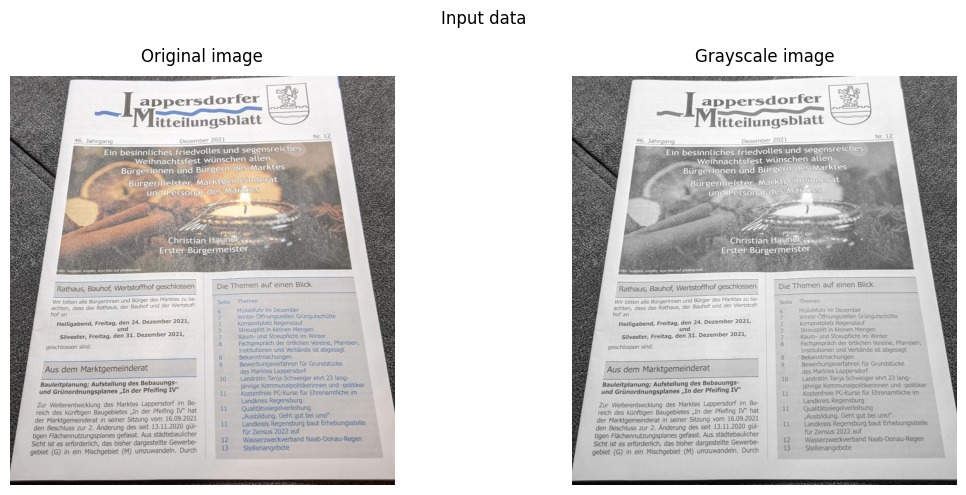

In [10]:
# Graphic results

import math
import numpy as np
import matplotlib.pyplot as plt

# Input data
n_img_cols = 2
images_dict = images_dict
n_img_rows = math.ceil(len(images_dict) / n_img_cols)

# Solution
_, axes = plt.subplots(n_img_rows, n_img_cols, figsize=(12, 5 * n_img_rows))
axes_list = np.array(axes).flatten()

for idx, (img_name, img_data) in enumerate(images_dict.items()):
    ax = axes_list[idx]
    ax.set_title(img_name, pad=10, loc='center', color='black')
    if len(img_data.shape) == 3:
        ax.imshow(img_data)
    else:
        ax.imshow(img_data, cmap='gray')
    ax.axis(False)

# remove empty charts
for idx in range(len(images_dict), len(axes_list)):
    axes_list[idx].remove()

# Plot
plt.suptitle("Input data")
plt.tight_layout()
plt.show()


First, let's have a look at the histogram.

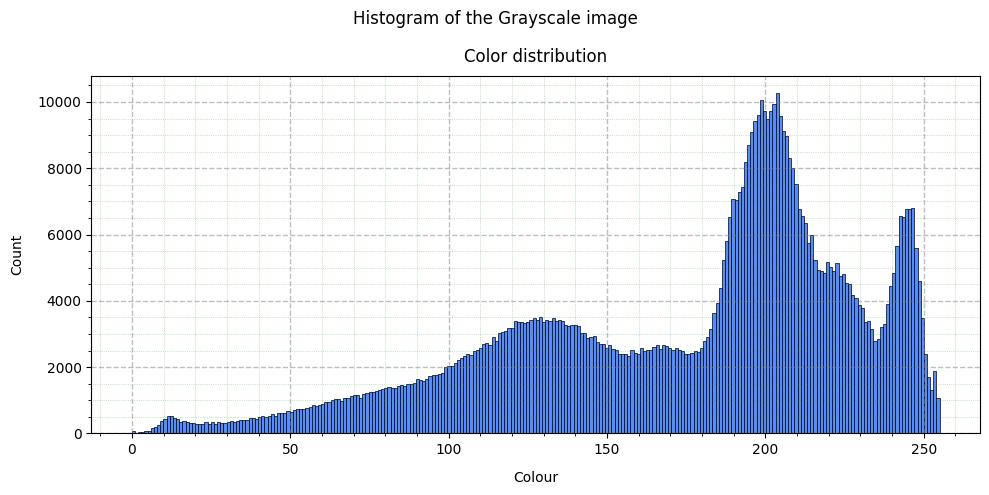

In [13]:
# Graphic results

import matplotlib.pyplot as plt

# Input data
n_bins = 256
data = img_gray.flatten()

# Solution
_, ax = plt.subplots(figsize=(10, 5))

ax.hist(data, bins=n_bins, edgecolor="black", linewidth=0.5)
ax.grid(axis='both', visible=True, which='major', ls='--', linewidth=1.0, color='tab:gray')
ax.minorticks_on()
ax.grid(axis='both', visible=True, which='minor', ls=':', linewidth=0.5, color='tab:green')
ax.set_title("Color distribution", pad=10, loc='center', color='black')
ax.set_xlabel("Colour", labelpad=10, loc='center', color='black')
ax.set_ylabel("Count", labelpad=10, loc='center', color='black')

plt.suptitle("Histogram of the Grayscale image")

plt.tight_layout()
plt.show()

### Otsu Thresholding

Let's now implement the Otsu thresholding algorithm. Remember that the algorithm consists of an optimization process that finds the thresholds that minimizes the intra-class variance or, equivalently, maximizes the inter-class variance.

In this homework, you are going to demonstrate the working principle of the Otsu algorithm. Therefore, you won't have to worry about an efficient implementation, we are going to use the brute force approach here.

In [ ]:
# Get image dimensions
rows, cols =
# Compute the total amount of image pixels
num_pixels =

# Initializations
best_wcv = 1e6  # Best within-class variance (wcv)
opt_th = None   # Threshold corresponding to the best wcv

# Brute force search using all possible thresholds (levels of gray)
for th in range(0, 256):
    # Extract the image pixels corresponding to the background
    foreground =
    # Extract the image pixels corresponding to the background
    background =
    
    # If foreground or background are empty, continue
    if len(foreground) == 0 or len(background) == 0:
        continue
    
    # Compute class-weights (omega parameters) for foreground and background
    omega_f =
    omega_b =
    
    # Compute pixel variance for foreground and background
    # Hint: Check out the var function from numpy ;-)
    # https://numpy.org/doc/stable/reference/generated/numpy.var.html
    sigma2_f =
    sigma2_b =
    
    # Compute the within-class variance
    wcv =
    
    # Perform the optimization
    if wcv < best_wcv:
        best =
        opt_th =
        
# Print out the optimal threshold found by Otsu algorithm
print('Optimal threshold', opt_th)

Finally, let's compare the original image and its thresholded representation.

In [ ]:
plt.subplot(121), plt.imshow(img, cmap='gray')
plt.subplot(122), plt.imshow(img > opt_th, cmap='gray')

### Questions

* Looking at the computed histogram, could it be considered bimodal?
* Looking at the computed histogram, what binarization threshold would you chose? Why?
* Looking at the resulting (thresholded) image, is the text binarization (detection) good?